
## 1. Chargement des données depuis HDFS

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.types import NumericType
from pyspark.sql import functions as F
from pyspark.sql.functions import when, col

'''
- Liste des port -
Jade     : 8020 
Flavien  : 9000
Samuel   :
Aimane   : 
Roissath : 9870

'''

port = "9000"
spark = SparkSession.builder \
    .appName("parsing_student_performance") \
    .config("spark.hadoop.dfs.client.use.datanode.hostname", "true") \
    .getOrCreate()
df = spark.read.csv(f"hdfs://localhost:{port}/projet/donnees/StudentPerformanceFactors_propre.csv", header=True, inferSchema=True)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/07/22 09:42:49 WARN Utils: Your hostname, Opa, resolves to a loopback address: 127.0.1.1; using 10.213.145.223 instead (on interface wlp61s0)
26/07/22 09:42:49 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/07/22 09:42:51 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
import os
os.environ['JAVA_HOME'] = '/opt/homebrew/opt/openjdk@17/libexec/openjdk.jdk/Contents/Home'

from pyspark.sql import SparkSession
from pyspark.sql.functions import when, col

'''
- Liste des port -
Jade     : 8020 
Flavien  : 9000
Samuel   :
Aimane   : 
Roissath : 9000
'''

port = "9000"
spark = SparkSession.builder.appName("parsing_student_performance").getOrCreate()
df = spark.read.csv(f"hdfs://localhost:{port}/projet/donnees/StudentPerformanceFactors_propre.csv", header=True, inferSchema=True)
df.show(5)

+---------------+--------+---------------------+--------------------+------------------------+--------------+-----------------+-----------------+--------------+----------------+--------------+------------------+----------+-------------------+-----------------+----------------------+------------------------+---------------+-----+------------+
|Heures_Etudiees|Presence|Implication_Parentale|Acces_aux_Ressources|Activites_Extrascolaires|Heures_Sommeil|Scores_Precedents|Niveau_Motivation|Acces_Internet|Sessions_Tutorat|Revenu_Famille|Qualite_Enseignant|Type_Ecole|Influence_Entourage|Activite_Physique|Troubles_Apprentissage|Niveau_Education_Parents|Distance_Maison|Genre|Score_Examen|
+---------------+--------+---------------------+--------------------+------------------------+--------------+-----------------+-----------------+--------------+----------------+--------------+------------------+----------+-------------------+-----------------+----------------------+------------------------+----

## 1.1 Transformation des données

In [4]:
# Mapping des colonnes (Anglais -> Français)
COLUMN_MAPPING = {
    "Hours_Studied": "Heures_Etudiees",
    "Attendance": "Presence",
    "Parental_Involvement": "Implication_Parentale",
    "Access_to_Resources": "Acces_aux_Ressources",
    "Extracurricular_Activities": "Activites_Extrascolaires",
    "Sleep_Hours": "Heures_Sommeil",
    "Previous_Scores": "Scores_Precedents",
    "Motivation_Level": "Niveau_Motivation",
    "Internet_Access": "Acces_Internet",
    "Tutoring_Sessions": "Sessions_Tutorat",
    "Family_Income": "Revenu_Famille",
    "Teacher_Quality": "Qualite_Enseignant",
    "School_Type": "Type_Ecole",
    "Peer_Influence": "Influence_Entourage",
    "Physical_Activity": "Activite_Physique",
    "Learning_Disabilities": "Troubles_Apprentissage",
    "Parental_Education_Level": "Niveau_Education_Parents",
    "Distance_from_Home": "Distance_Maison",
    "Gender": "Genre",
    "Exam_Score": "Score_Examen"
}

# Renommer les colonnes
for old_name, new_name in COLUMN_MAPPING.items():
    if old_name in df.columns:
        df = df.withColumnRenamed(old_name, new_name)

print("Colonnes renommées")

Colonnes renommées


In [5]:
# Traduction des valeurs catégorielles
cols_low_medium_high = ["Implication_Parentale", "Acces_aux_Ressources", "Niveau_Motivation", "Revenu_Famille", "Qualite_Enseignant"]
for c in cols_low_medium_high:
    if c in df.columns:
        df = df.withColumn(c, when(col(c) == "Low", "Bas").when(col(c) == "Medium", "Moyen").when(col(c) == "High", "Haut").otherwise(col(c)))

cols_yes_no = ["Activites_Extrascolaires", "Acces_Internet", "Troubles_Apprentissage"]
for c in cols_yes_no:
    if c in df.columns:
        df = df.withColumn(c, when(col(c) == "Yes", "Oui").when(col(c) == "No", "Non").otherwise(col(c)))

if "Type_Ecole" in df.columns:
    df = df.withColumn("Type_Ecole", when(col("Type_Ecole") == "Public", "Publique").when(col("Type_Ecole") == "Private", "Privee").otherwise(col("Type_Ecole")))

if "Influence_Entourage" in df.columns:
    df = df.withColumn("Influence_Entourage", when(col("Influence_Entourage") == "Negative", "Negative").when(col("Influence_Entourage") == "Neutral", "Neutre").when(col("Influence_Entourage") == "Positive", "Positif").otherwise(col("Influence_Entourage")))

if "Niveau_Education_Parents" in df.columns:
    df = df.withColumn("Niveau_Education_Parents", when(col("Niveau_Education_Parents") == "High School", "Lycee").when(col("Niveau_Education_Parents") == "College", "Licence").when(col("Niveau_Education_Parents") == "Postgraduate", "Master").otherwise(col("Niveau_Education_Parents")))

if "Distance_Maison" in df.columns:
    df = df.withColumn("Distance_Maison", when(col("Distance_Maison") == "Near", "Proche").when(col("Distance_Maison") == "Moderate", "Moderee").when(col("Distance_Maison") == "Far", "Loin").otherwise(col("Distance_Maison")))

if "Genre" in df.columns:
    df = df.withColumn("Genre", when(col("Genre") == "Male", "Homme").when(col("Genre") == "Female", "Femme").otherwise(col("Genre")))

print("Valeurs traduites")

Valeurs traduites


In [6]:
# Nettoyage : suppression des valeurs nulles et doublons
count_before = df.count()
df = df.dropna()
df = df.dropDuplicates()
count_after = df.count()

print(f"Lignes supprimées: {count_before - count_after}")
print(f"Lignes finales: {count_after}")
df.show(5)

Lignes supprimées: 0
Lignes finales: 6378
+---------------+--------+---------------------+--------------------+------------------------+--------------+-----------------+-----------------+--------------+----------------+--------------+------------------+----------+-------------------+-----------------+----------------------+------------------------+---------------+-----+------------+
|Heures_Etudiees|Presence|Implication_Parentale|Acces_aux_Ressources|Activites_Extrascolaires|Heures_Sommeil|Scores_Precedents|Niveau_Motivation|Acces_Internet|Sessions_Tutorat|Revenu_Famille|Qualite_Enseignant|Type_Ecole|Influence_Entourage|Activite_Physique|Troubles_Apprentissage|Niveau_Education_Parents|Distance_Maison|Genre|Score_Examen|
+---------------+--------+---------------------+--------------------+------------------------+--------------+-----------------+-----------------+--------------+----------------+--------------+------------------+----------+-------------------+-----------------+----------

## 2. Encodage des variables catégorielles

In [7]:
df = df.withColumn(
    "Implication_Parentale_num",
    when(df.Implication_Parentale == "Haut", 2)
    .when(df.Implication_Parentale == "Moyen", 1)
    .when(df.Implication_Parentale == "Bas", 0)
)

df = df.withColumn(
    "Influence_Entourage_num",
    when(df.Influence_Entourage == "Negative", -1)
    .when(df.Influence_Entourage == "Positif", 1)
    .when(df.Influence_Entourage == "Neutre", 0)
)

df = df.withColumn(
    "Acces_aux_Ressources_num",
    when(df.Acces_aux_Ressources == "Bas", 0)
    .when(df.Acces_aux_Ressources == "Moyen", 1)
    .when(df.Acces_aux_Ressources == "Haut", 2)
)

df = df.withColumn(
    "Niveau_Motivation_num",
    when(df.Niveau_Motivation == "Bas", 0)
    .when(df.Niveau_Motivation == "Moyen", 1)
    .when(df.Niveau_Motivation == "Haut", 2)
)

df = df.withColumn(
    "Qualite_Enseignant_num",
    when(df.Qualite_Enseignant == "Bas", 0)
    .when(df.Qualite_Enseignant == "Moyen", 1)
    .when(df.Qualite_Enseignant == "Haut", 2)
)

df = df.withColumn(
    "Revenu_Famille_num",
    when(df.Revenu_Famille == "Bas", 0)
    .when(df.Revenu_Famille == "Moyen", 1)
    .when(df.Revenu_Famille == "Haut", 2)
)

df = df.withColumn(
    "Distance_Maison_num",
    when(df.Distance_Maison == "Proche", 0)
    .when(df.Distance_Maison == "Moderee", 1)
    .when(df.Distance_Maison == "Loin", 2)
)

df = df.withColumn(
    "Niveau_Education_Parents_num",
    when(df.Niveau_Education_Parents == "Lycee", 0)
    .when(df.Niveau_Education_Parents == "Licence", 1)
    .when(df.Niveau_Education_Parents == "Master", 2)
)

df = df.withColumn(
    "Activites_Extrascolaires_num",
    when(df.Activites_Extrascolaires == "Oui", 1)
    .when(df.Activites_Extrascolaires == "Non", 0)
)

df = df.withColumn(
    "Troubles_Apprentissage_num",
    when(df.Troubles_Apprentissage == "Oui", 1)
    .when(df.Troubles_Apprentissage == "Non", 0)
)

df = df.withColumn(
    "Acces_Internet_num",
    when(df.Acces_Internet == "Oui", 1)
    .when(df.Acces_Internet == "Non", 0)
)

df = df.withColumn(
    "Type_Ecole_num",
    when(df.Type_Ecole == "Privee", 1)
    .when(df.Type_Ecole == "Publique", 0)
)

df = df.withColumn(
    "Genre_num",
    when(df.Genre == "Femme", 1)
    .when(df.Genre == "Homme", 0)
)

df = df.dropDuplicates()

## 3. Stat - Samuel

### 3.1 Vue d'ensemble

In [8]:
nb_lignes = df.count()  
print(f"Nombre de lignes  : {nb_lignes}")
print(f"Nombre de colonnes: {len(df.columns)}")

colonnes_numeriques = [f.name for f in df.schema.fields if isinstance(f.dataType, NumericType)]
colonnes_categorielles = [c for c in df.columns if c not in colonnes_numeriques]

print("Colonnes numériques   :", colonnes_numeriques)
print("Colonnes catégorielles:", colonnes_categorielles)

26/07/22 09:45:07 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


Nombre de lignes  : 6378
Nombre de colonnes: 33
Colonnes numériques   : ['Heures_Etudiees', 'Presence', 'Heures_Sommeil', 'Scores_Precedents', 'Sessions_Tutorat', 'Activite_Physique', 'Score_Examen', 'Implication_Parentale_num', 'Influence_Entourage_num', 'Acces_aux_Ressources_num', 'Niveau_Motivation_num', 'Qualite_Enseignant_num', 'Revenu_Famille_num', 'Distance_Maison_num', 'Niveau_Education_Parents_num', 'Activites_Extrascolaires_num', 'Troubles_Apprentissage_num', 'Acces_Internet_num', 'Type_Ecole_num', 'Genre_num']
Colonnes catégorielles: ['Implication_Parentale', 'Acces_aux_Ressources', 'Activites_Extrascolaires', 'Niveau_Motivation', 'Acces_Internet', 'Revenu_Famille', 'Qualite_Enseignant', 'Type_Ecole', 'Influence_Entourage', 'Troubles_Apprentissage', 'Niveau_Education_Parents', 'Distance_Maison', 'Genre']


### 3.2 Variables numériques 


In [9]:
agg_exprs = []
for c in colonnes_numeriques:
    agg_exprs += [
        F.count(c).alias(f"{c}__count"),
        F.mean(c).alias(f"{c}__mean"),
        F.stddev(c).alias(f"{c}__stddev"),
        F.variance(c).alias(f"{c}__variance"),
        F.min(c).alias(f"{c}__min"),
        F.max(c).alias(f"{c}__max"),
    ]

resultat_df = df.agg(*agg_exprs)  # une seule ligne "large", calcul distribué

# On "dépivote" cette ligne large en un tableau long (1 ligne par variable) via stack(),
n = len(colonnes_numeriques)
valeurs_stack = ", ".join([
    f"'{c}', round(`{c}__count`, 3), round(`{c}__mean`, 3), round(`{c}__stddev`, 3), "
    f"round(`{c}__variance`, 3), round(`{c}__min`, 3), round(`{c}__max`, 3)"
    for c in colonnes_numeriques
])
stack_expr = f"stack({n}, {valeurs_stack}) as (Variable, Count, Moyenne, Ecart_type, Variance, Min, Max)"

stats_numeriques_df = resultat_df.selectExpr(stack_expr)
stats_numeriques_df.show(truncate=False)

import csv, os
os.makedirs("../app/cache", exist_ok=True)
rows = stats_numeriques_df.collect()
with open("../app/cache/samuel_stats_numeriques.csv", "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(stats_numeriques_df.columns)
    for row in rows:
        writer.writerow([row[c] for c in stats_numeriques_df.columns])
print("Exporte vers app/cache/samuel_stats_numeriques.csv")

+----------------------------+-----+-------+----------+--------+---+---+
|Variable                    |Count|Moyenne|Ecart_type|Variance|Min|Max|
+----------------------------+-----+-------+----------+--------+---+---+
|Heures_Etudiees             |6378 |19.977 |5.985     |35.826  |1  |44 |
|Presence                    |6378 |80.021 |11.551    |133.419 |60 |100|
|Heures_Sommeil              |6378 |7.035  |1.468     |2.155   |4  |10 |
|Scores_Precedents           |6378 |75.066 |14.4      |207.371 |50 |100|
|Sessions_Tutorat            |6378 |1.495  |1.234     |1.523   |0  |8  |
|Activite_Physique           |6378 |2.973  |1.029     |1.059   |0  |6  |
|Score_Examen                |6378 |67.252 |3.914     |15.321  |55 |101|
|Implication_Parentale_num   |6378 |1.085  |0.695     |0.483   |0  |2  |
|Influence_Entourage_num     |6378 |0.192  |0.756     |0.572   |-1 |1  |
|Acces_aux_Ressources_num    |6378 |1.098  |0.699     |0.488   |0  |2  |
|Niveau_Motivation_num       |6378 |0.908  |0.696  

Exporte vers app/cache/samuel_stats_numeriques.csv


### 3.3 Quartiles

In [10]:
RELATIVE_ERROR = 0.01
lignes_quantiles_sql = []
conditions_outliers = {}

for c in colonnes_numeriques:
    q1, med, q3 = df.approxQuantile(c, [0.25, 0.5, 0.75], RELATIVE_ERROR)
    iqr = q3 - q1
    borne_basse = q1 - 1.5 * iqr
    borne_haute = q3 + 1.5 * iqr

    lignes_quantiles_sql.append(
        f"'{c}', CAST({q1} AS DOUBLE), CAST({med} AS DOUBLE), CAST({q3} AS DOUBLE), "
        f"CAST({iqr} AS DOUBLE), CAST({borne_basse} AS DOUBLE), CAST({borne_haute} AS DOUBLE)"
    )
    conditions_outliers[c] = (F.col(c) < borne_basse) | (F.col(c) > borne_haute)

n = len(colonnes_numeriques)
valeurs_stack = ", ".join(lignes_quantiles_sql)
stack_expr = f"stack({n}, {valeurs_stack}) as (Variable, Q1, Mediane, Q3, IQR, Borne_basse, Borne_haute)"

quantiles_df = spark.range(1).selectExpr(stack_expr) \
    .withColumn("Q1", F.round("Q1", 3)) \
    .withColumn("Mediane", F.round("Mediane", 3)) \
    .withColumn("Q3", F.round("Q3", 3)) \
    .withColumn("IQR", F.round("IQR", 3)) \
    .withColumn("Borne_basse", F.round("Borne_basse", 3)) \
    .withColumn("Borne_haute", F.round("Borne_haute", 3))

quantiles_df.show(truncate=False)

rows = quantiles_df.collect()
with open("../app/cache/samuel_quartiles.csv", "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(quantiles_df.columns)
    for row in rows:
        writer.writerow([row[c] for c in quantiles_df.columns])
print("Exporte vers app/cache/samuel_quartiles.csv")

+----------------------------+----+-------+----+----+-----------+-----------+
|Variable                    |Q1  |Mediane|Q3  |IQR |Borne_basse|Borne_haute|
+----------------------------+----+-------+----+----+-----------+-----------+
|Heures_Etudiees             |16.0|20.0   |24.0|8.0 |4.0        |36.0       |
|Presence                    |70.0|80.0   |90.0|20.0|40.0       |120.0      |
|Heures_Sommeil              |6.0 |7.0    |8.0 |2.0 |3.0        |11.0       |
|Scores_Precedents           |62.0|75.0   |87.0|25.0|24.5       |124.5      |
|Sessions_Tutorat            |1.0 |1.0    |2.0 |1.0 |-0.5       |3.5        |
|Activite_Physique           |2.0 |3.0    |4.0 |2.0 |-1.0       |7.0        |
|Score_Examen                |65.0|67.0   |69.0|4.0 |59.0       |75.0       |
|Implication_Parentale_num   |1.0 |1.0    |2.0 |1.0 |-0.5       |3.5        |
|Influence_Entourage_num     |0.0 |0.0    |1.0 |1.0 |-1.5       |2.5        |
|Acces_aux_Ressources_num    |1.0 |1.0    |2.0 |1.0 |-0.5       

### 3.4 Variables catégorielles 

In [12]:
frequences = {}

for c in colonnes_categorielles:
    freq_df = df.groupBy(c).count() \
        .withColumn("Pourcentage", F.round(100 * F.col("count") / nb_lignes, 2)) \
        .orderBy(F.col("count").desc()) \
        .withColumnRenamed(c, "Modalite") \
        .withColumnRenamed("count", "Effectif")

    frequences[c] = freq_df  # DataFrame Spark, reste distribué

# Table des modes : on construit directement en Spark avec Window + row_number,
# plutôt que de ramener une ligne par variable côté driver
from pyspark.sql.window import Window

mode_df = None
for c, freq_df in frequences.items():
    top1 = freq_df.withColumn("Variable", F.lit(c)) \
        .withColumn("rang", F.row_number().over(Window.orderBy(F.col("Effectif").desc()))) \
        .filter(F.col("rang") == 1) \
        .select("Variable", F.col("Modalite").alias("Mode"),
                F.col("Effectif").alias("Effectif_mode"),
                F.col("Pourcentage").alias("Pct_mode"))
    mode_df = top1 if mode_df is None else mode_df.union(top1)

mode_df.show(truncate=False)

26/07/22 09:46:59 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/07/22 09:46:59 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/07/22 09:46:59 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/07/22 09:46:59 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/07/22 09:46:59 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/07/22 09:46:59 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/07/22 0

+------------------------+--------+-------------+--------+
|Variable                |Mode    |Effectif_mode|Pct_mode|
+------------------------+--------+-------------+--------+
|Implication_Parentale   |Moyen   |3251         |50.97   |
|Acces_aux_Ressources    |Moyen   |3204         |50.24   |
|Activites_Extrascolaires|Oui     |3807         |59.69   |
|Niveau_Motivation       |Moyen   |3237         |50.75   |
|Acces_Internet          |Oui     |5893         |92.4    |
|Revenu_Famille          |Bas     |2582         |40.48   |
|Qualite_Enseignant      |Moyen   |3826         |59.99   |
|Type_Ecole              |Publique|4434         |69.52   |
|Influence_Entourage     |Positif |2553         |40.03   |
|Troubles_Apprentissage  |Non     |5710         |89.53   |
|Niveau_Education_Parents|Lycee   |3159         |49.53   |
|Distance_Maison         |Proche  |3801         |59.6    |
|Genre                   |Homme   |3688         |57.82   |
+------------------------+--------+-------------+-------

In [13]:
# Pour afficher le détail de toutes les variables catégorielles :
for c, freq_df in frequences.items():
    print(f"\n--- {c} ---")
    freq_df.show(truncate=False)


--- Implication_Parentale ---
+--------+--------+-----------+
|Modalite|Effectif|Pourcentage|
+--------+--------+-----------+
|Moyen   |3251    |50.97      |
|Haut    |1836    |28.79      |
|Bas     |1291    |20.24      |
+--------+--------+-----------+


--- Acces_aux_Ressources ---
+--------+--------+-----------+
|Modalite|Effectif|Pourcentage|
+--------+--------+-----------+
|Moyen   |3204    |50.24      |
|Haut    |1900    |29.79      |
|Bas     |1274    |19.97      |
+--------+--------+-----------+


--- Activites_Extrascolaires ---
+--------+--------+-----------+
|Modalite|Effectif|Pourcentage|
+--------+--------+-----------+
|Oui     |3807    |59.69      |
|Non     |2571    |40.31      |
+--------+--------+-----------+


--- Niveau_Motivation ---
+--------+--------+-----------+
|Modalite|Effectif|Pourcentage|
+--------+--------+-----------+
|Moyen   |3237    |50.75      |
|Bas     |1864    |29.23      |
|Haut    |1277    |20.02      |
+--------+--------+-----------+


--- Acces

In [14]:
freq_rows = []
for c, freq_df in frequences.items():
    for row in freq_df.collect():
        freq_rows.append({
            "Variable": c,
            "Modalite": row["Modalite"],
            "Effectif": row["Effectif"],
            "Pourcentage": row["Pourcentage"],
        })

with open("../app/cache/samuel_frequences.csv", "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=["Variable", "Modalite", "Effectif", "Pourcentage"])
    writer.writeheader()
    writer.writerows(freq_rows)

print(f"{len(freq_rows)} lignes exportees vers app/cache/samuel_frequences.csv")


34 lignes exportees vers app/cache/samuel_frequences.csv


## 4. Identification des features importantes

### 4.1 Clear des lignes contenant des NULL

In [15]:
for i in df.columns:
    i, ":", df.filter(col(i).isNull()).count()

## 4.2 Scoring d'influence des features

In [16]:
colonnes_num = [
    "Heures_Etudiees"
    ,"Presence"
    ,"Heures_Sommeil"
    ,"Scores_Precedents"
    ,"Sessions_Tutorat"
    ,"Activite_Physique"
    ,"Implication_Parentale_num"
    ,"Influence_Entourage_num"
    ,"Acces_aux_Ressources_num"
    ,"Niveau_Motivation_num"
    ,"Qualite_Enseignant_num"
    ,"Revenu_Famille_num"
    ,"Distance_Maison_num"
    ,"Niveau_Education_Parents_num"
    ,"Activites_Extrascolaires_num",
    "Troubles_Apprentissage_num"
    ,"Acces_Internet_num"
    ,"Type_Ecole_num"
    ,"Genre_num"
]

correlations = {}

for c in colonnes_num:
    correlations[c] = df.corr(c, "Score_Examen")

for c, corr in correlations.items():
    print(f"{c} : {round(corr, 4)}")

Heures_Etudiees : 0.4451
Presence : 0.5803
Heures_Sommeil : -0.0172
Scores_Precedents : 0.1743
Sessions_Tutorat : 0.1568
Activite_Physique : 0.0251
Implication_Parentale_num : 0.156
Influence_Entourage_num : 0.0991
Acces_aux_Ressources_num : 0.1679
Niveau_Motivation_num : 0.0885
Qualite_Enseignant_num : 0.0751
Revenu_Famille_num : 0.0946
Distance_Maison_num : -0.0881
Niveau_Education_Parents_num : 0.1053
Activites_Extrascolaires_num : 0.0631
Troubles_Apprentissage_num : -0.0839
Acces_Internet_num : 0.0511
Type_Ecole_num : 0.0109
Genre_num : 0.0049


### Recuperation des features les plus impactantes

In [17]:
sorted_cor = sorted(correlations.items(), key=lambda x: abs(x[1]), reverse=True)

top5 = sorted_cor[:5]

print(top5)

[('Presence', 0.5802585402382587), ('Heures_Etudiees', 0.4451041402651174), ('Scores_Precedents', 0.174283049003179), ('Acces_aux_Ressources_num', 0.16785600902892453), ('Sessions_Tutorat', 0.15682926320393245)]


In [ ]:
## 3.3 Prediction de score a l'exam en fonction des features importantes

### De Spark a pandas a keras

In [18]:
import numpy as np
import pandas as pd

features = [c for c, _ in top5]
cible = "Score_Examen"

pdf = df.select(features + [cible]).toPandas()
pdf = pdf.dropna()

X = pdf[features].values
y = pdf[cible].values

print(X.shape, y.shape)

(6378, 5) (6378,)


### Split et normalisation

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### PMC Keras

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras # type: ignore
from tensorflow.keras import layers # type: ignore

modele = keras.Sequential([
    layers.Input(shape=(len(features),)),
    layers.Dense(32, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1)
])

modele.compile(optimizer="adam", loss="mse")

historique = modele.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0
)

print("Entrainement termine")

Entrainement termine


MSE test  : 4.880


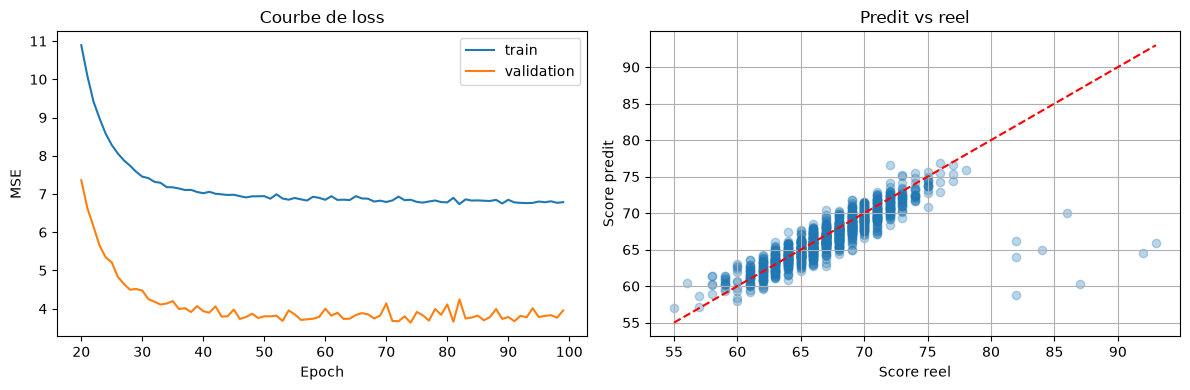

In [31]:
from sklearn.metrics import mean_squared_error

y_pred = modele.predict(X_test, verbose=0).flatten()
mse = mean_squared_error(y_test, y_pred)

print(f"MSE test  : {mse:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

n_skip = 20
epochs = range(n_skip, len(historique.history["loss"]))

axes[0].plot(epochs, historique.history["loss"][n_skip:], label="train")
axes[0].plot(epochs, historique.history["val_loss"][n_skip:], label="validation")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE")
axes[0].set_title("Courbe de loss")
axes[0].legend()

# Predit vs reel
axes[1].scatter(y_test, y_pred, alpha=0.3)
axes[1].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], "r--")
axes[1].set_xlabel("Score reel")
axes[1].set_ylabel("Score predit")
axes[1].set_title("Predit vs reel")

plt.grid(True)
plt.tight_layout()
plt.show()

### Test sur de nouvelles données

In [20]:
print("Ordre des features :", features)

# Ordre des features :
# [0] Presence                  : % de presence en cours (60-100)
# [1] Heures_Etudiees           : heures d'etude par semaine (0-45)
# [2] Scores_Precedents         : score aux exams precedents (50-100)
# [3] Acces_aux_Ressources_num  : 0=Bas, 1=Moyen, 2=Haut
# [4] Sessions_Tutorat          : nb de sessions de tutorat (0-8)

nouveaux = np.array([
    [95, 30, 85, 2, 5],   # eleve assidu, bien equipe
    [60, 5,  50, 0, 0],   # eleve absent, peu de moyens
    [80, 20, 70, 1, 2],   # profil moyen
])

# Normalisation
nouveaux_scaled = scaler.transform(nouveaux)

predictions = modele.predict(nouveaux_scaled, verbose=0).flatten()

for valeurs, score in zip(nouveaux, predictions):
    print(f"{valeurs} -> score predit : {score:.1f}")

Ordre des features : ['Presence', 'Heures_Etudiees', 'Scores_Precedents', 'Acces_aux_Ressources_num', 'Sessions_Tutorat']


NameError: name 'scaler' is not defined